<a href="https://colab.research.google.com/github/Anad4rc/Desafio-Alura-Store/blob/main/AluraStoreBr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importação dos dados



In [12]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja = pd.read_csv(url)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

loja.head()

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38


#1. Análise do faturamento


In [13]:
# Calculando faturamento total de cada loja
faturamento_loja1 = loja['Preço'].sum()
faturamento_loja2 = loja2['Preço'].sum()
faturamento_loja3 = loja3['Preço'].sum()
faturamento_loja4 = loja4['Preço'].sum()

# Exibindo os resultados
print('Faturamento loja 1: R$ ', faturamento_loja1)
print('Faturamento loja 2: R$ ', faturamento_loja2)
print('Faturamento loja 3: R$ ', faturamento_loja3)
print('Faturamento loja 4: R$ ', faturamento_loja4)

Faturamento loja 1: R$  1534509.12
Faturamento loja 2: R$  1488459.06
Faturamento loja 3: R$  1464025.03
Faturamento loja 4: R$  1384497.58


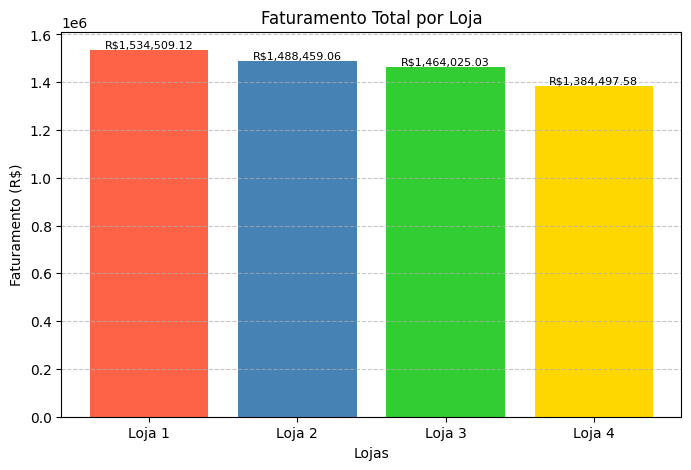

In [14]:
# Mostrando gráfico de barras com a soma de faturamento de cada loja, soma da coluna 'Preço'
import matplotlib.pyplot as plt

# Dados
faturamentos = [faturamento_loja1, faturamento_loja2, faturamento_loja3, faturamento_loja4]
lojas = ['Loja 1', 'Loja 2', 'Loja 3', 'Loja 4']

# Definindo uma lista de cores diferentes para as barras
cores = ['#FF6347', '#4682B4', '#32CD32', '#FFD700']  # Aqui você pode colocar qualquer cor ou usar códigos hexadecimais

# Criando Gráfico de barras
plt.figure(figsize=(8,5))
barras = plt.bar(lojas, faturamentos, color=cores)  # Obtendo o objeto das barras para poder trabalhar com ele

# Adicionando os valores em cima de cada barra
for i, barra in enumerate(barras):
    altura = barra.get_height()  # Obtém a altura da barra (faturamento)
    plt.text(barra.get_x() + barra.get_width() / 2, altura + 10,  # Posição do texto (meio da barra e um pouco acima)
             f'R${faturamentos[i]:,.2f}',  # Formatação do valor (faturamento)
             ha='center', va='bottom', fontsize=8, color='black')  # Alinhamento e estilo

# Título e as labels
plt.title('Faturamento Total por Loja')
plt.ylabel('Faturamento (R$)')
plt.xlabel('Lojas')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# 2. Vendas por Categoria


In [15]:
# Agrupar por categoria e contar os produtos vendidos em cada categoria
qtd_por_categoria_loja1 = loja.groupby('Categoria do Produto').size()
qtd_por_categoria_loja2 = loja2.groupby('Categoria do Produto').size()
qtd_por_categoria_loja3 = loja3.groupby('Categoria do Produto').size()
qtd_por_categoria_loja4 = loja4.groupby('Categoria do Produto').size()

'''
# Exibir resultado
print(qtd_por_categoria_loja1)
print(qtd_por_categoria_loja2)
print(qtd_por_categoria_loja3)
print(qtd_por_categoria_loja4)
'''
# Criando um DataFrame com as categorias como índice e as colunas sendo as lojas
df_categorias = pd.DataFrame({
    'Loja 1': loja.groupby('Categoria do Produto').size(),
    'Loja 2': loja2.groupby('Categoria do Produto').size(),
    'Loja 3': loja3.groupby('Categoria do Produto').size(),
    'Loja 4': loja4.groupby('Categoria do Produto').size(),
}).fillna(0).astype(int) # Vai preencher com 0 onde não há categoria e transforma em int

# Imprime a tabela
print(df_categorias)


                       Loja 1  Loja 2  Loja 3  Loja 4
Categoria do Produto                                 
brinquedos                324     313     315     338
eletrodomesticos          312     305     278     254
eletronicos               448     422     451     451
esporte e lazer           284     275     277     277
instrumentos musicais     182     224     177     170
livros                    173     197     185     187
moveis                    465     442     499     480
utilidades domesticas     171     181     177     201


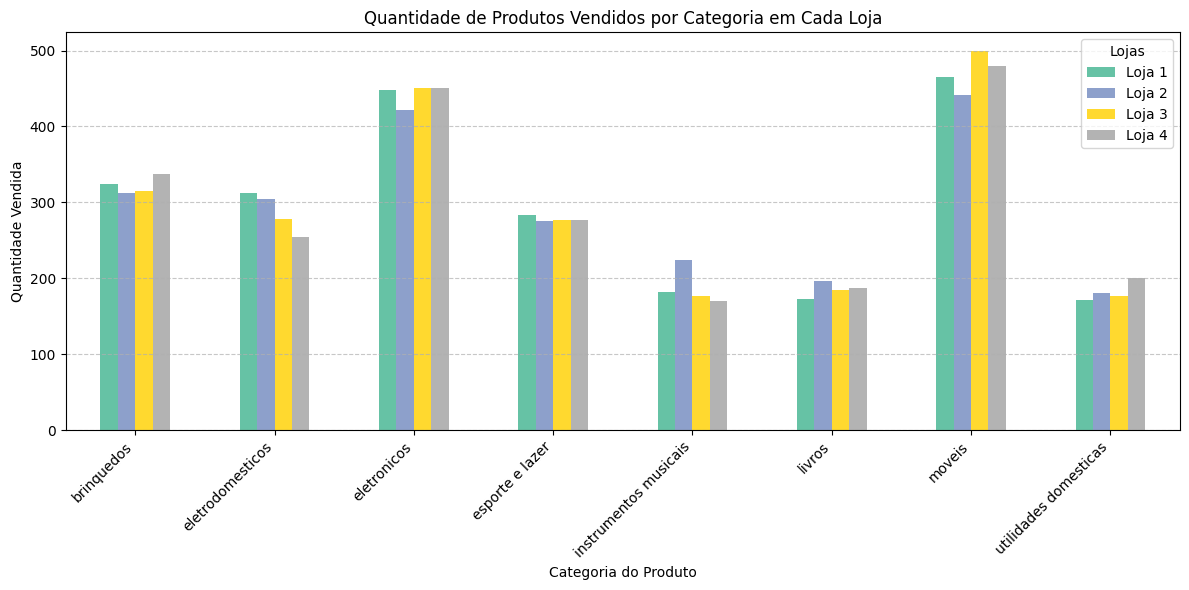

In [16]:
import matplotlib.pyplot as plt

# Criar o gráfico de barras agrupadas
df_categorias.plot(kind='bar', figsize=(12, 6), colormap='Set2')

plt.title('Quantidade de Produtos Vendidos por Categoria em Cada Loja')
plt.xlabel('Categoria do Produto')
plt.ylabel('Quantidade Vendida')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Lojas')
plt.tight_layout()
plt.show()


# 3. Média de Avaliação das Lojas

In [17]:
# Calculando a média das avaliações de cada uma das lojas
media_avaliacao_loja1 = loja['Avaliação da compra'].mean()
media_avaliacao_loja2 = loja2['Avaliação da compra'].mean()
media_avaliacao_loja3 = loja3['Avaliação da compra'].mean()
media_avaliacao_loja4 = loja4['Avaliação da compra'].mean()

# Exibindo os resultados
print(f'Média de Avaliação da Loja 1: {media_avaliacao_loja1:.2f}')
print(f'Média de Avaliação da Loja 2: {media_avaliacao_loja2:.2f}')
print(f'Média de Avaliação da Loja 3: {media_avaliacao_loja3:.2f}')
print(f'Média de Avaliação da Loja 4: {media_avaliacao_loja4:.2f}')

Média de Avaliação da Loja 1: 3.98
Média de Avaliação da Loja 2: 4.04
Média de Avaliação da Loja 3: 4.05
Média de Avaliação da Loja 4: 4.00


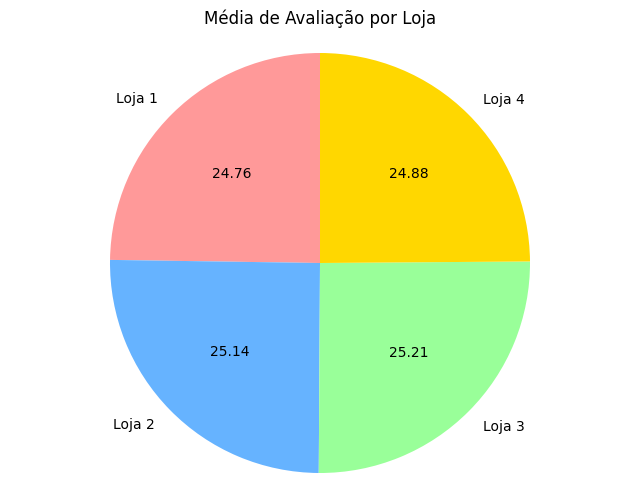

In [18]:
import matplotlib.pyplot as plt

# Dados das médias de avaliação
medias_avaliacao = [
    media_avaliacao_loja1,
    media_avaliacao_loja2,
    media_avaliacao_loja3,
    media_avaliacao_loja4
]

lojas = ['Loja 1', 'Loja 2', 'Loja 3', 'Loja 4']
cores = ['#FF9999', '#66B3FF', '#99FF99', '#FFD700']  # Cores para cada loja

# Criando o gráfico de pizza
plt.figure(figsize=(8, 6))
plt.pie(medias_avaliacao, labels=lojas, autopct='%.2f', startangle=90, colors=cores)
plt.title('Média de Avaliação por Loja')
plt.axis('equal')  # Deixa o gráfico com formato de círculo
plt.show()

# 4. Produtos Mais e Menos Vendidos

In [19]:
import matplotlib.pyplot as plt

# Função para exibir os produtos mais e menos vendidos
def obter_produtos_mais_e_menos_vendidos(df_loja):
    # Contagem de vendas por produto
    produtos_vendidos = df_loja['Produto'].value_counts()

    # Selecionar os 5 produtos mais vendidos
    top_5_melhores = produtos_vendidos.head(5)

    # Selecionar os 5 produtos menos vendidos
    top_5_piores = produtos_vendidos.tail(5)
    return top_5_melhores, top_5_piores

# Resultados para cada loja
top_5_melhores_loja1, top_5_piores_loja1 = obter_produtos_mais_e_menos_vendidos(loja)
top_5_melhores_loja2, top_5_piores_loja2 = obter_produtos_mais_e_menos_vendidos(loja2)
top_5_melhores_loja3, top_5_piores_loja3 = obter_produtos_mais_e_menos_vendidos(loja3)
top_5_melhores_loja4, top_5_piores_loja4 = obter_produtos_mais_e_menos_vendidos(loja4)

# Exibindo os resultados
print("Loja 1:")
print("Top 5 mais vendidos:\n", top_5_melhores_loja1)
print("Top 5 menos vendidos:\n", top_5_piores_loja1)

print("\nLoja 2:")
print("Top 5 mais vendidos:\n", top_5_melhores_loja2)
print("Top 5 menos vendidos:\n", top_5_piores_loja2)

print("\nLoja 3:")
print("Top 5 mais vendidos:\n", top_5_melhores_loja3)
print("Top 5 menos vendidos:\n", top_5_piores_loja3)

print("\nLoja 4:")
print("Top 5 mais vendidos:\n", top_5_melhores_loja4)
print("Top 5 menos vendidos:\n", top_5_piores_loja4)


Loja 1:
Top 5 mais vendidos:
 Produto
Micro-ondas           60
TV Led UHD 4K         60
Guarda roupas         60
Secadora de roupas    58
Cômoda                56
Name: count, dtype: int64
Top 5 menos vendidos:
 Produto
Ciência de dados com python    39
Pandeiro                       36
Panela de pressão              35
Headset                        33
Celular ABXY                   33
Name: count, dtype: int64

Loja 2:
Top 5 mais vendidos:
 Produto
Iniciando em programação    65
Micro-ondas                 62
Bateria                     61
Violão                      58
Pandeiro                    58
Name: count, dtype: int64
Top 5 menos vendidos:
 Produto
Fone de ouvido       37
Poltrona             35
Mesa de jantar       34
Impressora           34
Jogo de tabuleiro    32
Name: count, dtype: int64

Loja 3:
Top 5 mais vendidos:
 Produto
Kit banquetas      57
Mesa de jantar     56
Cama king          56
Jogo de panelas    55
Cômoda             55
Name: count, dtype: int64
Top 5 menos 

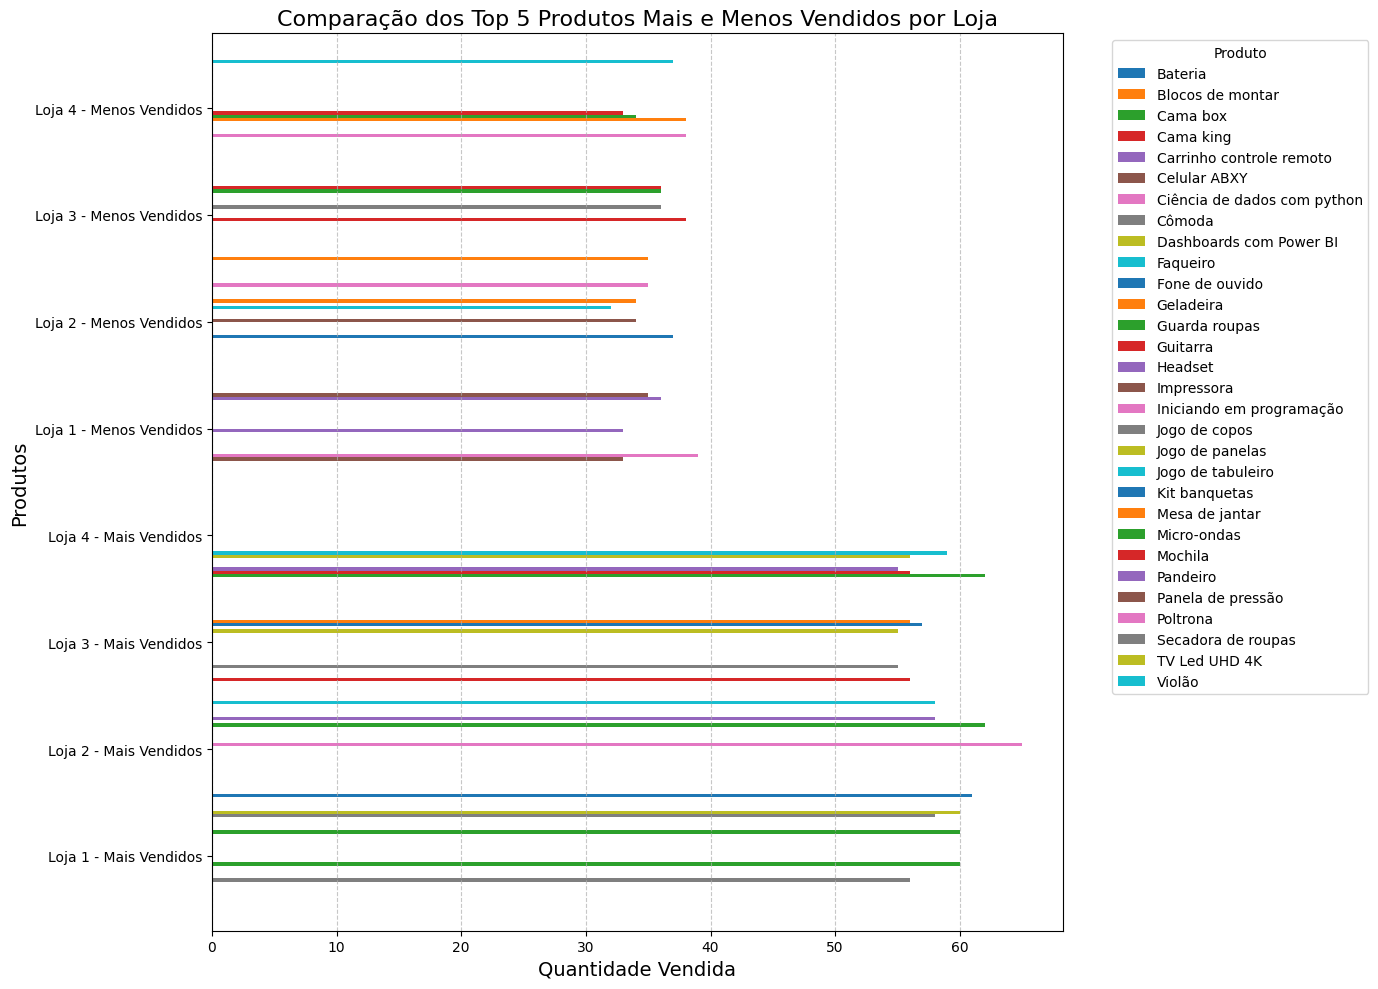

In [20]:
import matplotlib.pyplot as plt

# Captura os 5 produtos mais vendidos e 5 menos vendidos por loja
top5_loja1 = loja['Produto'].value_counts().head(5)
top5_loja2 = loja2['Produto'].value_counts().head(5)
top5_loja3 = loja3['Produto'].value_counts().head(5)
top5_loja4 = loja4['Produto'].value_counts().head(5)

# Captura os 5 produtos menos vendidos por loja
bottom5_loja1 = loja['Produto'].value_counts().tail(5)
bottom5_loja2 = loja2['Produto'].value_counts().tail(5)
bottom5_loja3 = loja3['Produto'].value_counts().tail(5)
bottom5_loja4 = loja4['Produto'].value_counts().tail(5)

# Cria um DataFrame com esses dados combinados para produtos mais e menos vendidos
df_top_bottom_comparado = pd.DataFrame({
    'Loja 1 - Mais Vendidos': top5_loja1,
    'Loja 2 - Mais Vendidos': top5_loja2,
    'Loja 3 - Mais Vendidos': top5_loja3,
    'Loja 4 - Mais Vendidos': top5_loja4,
    'Loja 1 - Menos Vendidos': bottom5_loja1,
    'Loja 2 - Menos Vendidos': bottom5_loja2,
    'Loja 3 - Menos Vendidos': bottom5_loja3,
    'Loja 4 - Menos Vendidos': bottom5_loja4
}).fillna(0)

# Transpõe para facilitar a plotagem do gráfico
df_top_bottom_comparado = df_top_bottom_comparado.T

# Gráfico de barras horizontais
ax = df_top_bottom_comparado.plot(kind='barh', figsize=(14,10), width=0.9)

# Ajustando título, labels e grid
plt.title('Comparação dos Top 5 Produtos Mais e Menos Vendidos por Loja', fontsize=16)
plt.xlabel('Quantidade Vendida', fontsize=14)
plt.ylabel('Produtos', fontsize=14)

# Colocando a legenda fora do gráfico para evitar sobreposição
plt.legend(title='Produto', bbox_to_anchor=(1.05, 1), loc='upper left')

# Melhorando o layout e a grid
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# Exibindo o gráfico
plt.show()


# 5. Frete Médio por Loja


In [21]:
# Calculando o frete médio das lojas

# 'loja' é o DataFrame da Loja 1
# 'Frete' é a coluna do DataFrame que contém os valores do frete
# O método '.mean()' calcula a média dos valores dessa coluna, ou seja, o frete médio da Loja 1
frete_medio_loja1 = loja['Frete'].mean()
frete_medio_loja2 = loja2['Frete'].mean()
frete_medio_loja3 = loja3['Frete'].mean()
frete_medio_loja4 = loja4['Frete'].mean()

print(f'Frete Médio da Loja 1: R${frete_medio_loja1:.2f}')
print(f'Frete Médio da Loja 2: R${frete_medio_loja2:.2f}')
print(f'Frete Médio da Loja 3: R${frete_medio_loja3:.2f}')
print(f'Frete Médio da Loja 4: R${frete_medio_loja4:.2f}')


Frete Médio da Loja 1: R$34.69
Frete Médio da Loja 2: R$33.62
Frete Médio da Loja 3: R$33.07
Frete Médio da Loja 4: R$31.28


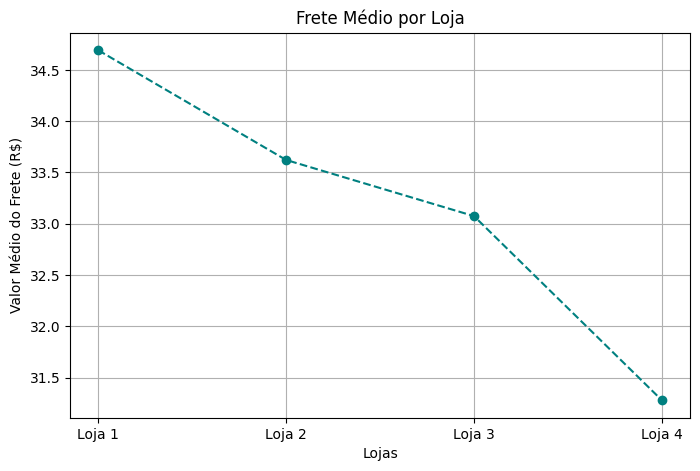

In [22]:
import matplotlib.pyplot as plt

fretes = [frete_medio_loja1, frete_medio_loja2, frete_medio_loja3, frete_medio_loja4]
lojas = ['Loja 1', 'Loja 2', 'Loja 3', 'Loja 4']

# Criando Gráfico de linha
plt.figure(figsize=(8, 5))
plt.plot(lojas, fretes, marker='o', linestyle='--', color='teal')
plt.title('Frete Médio por Loja')
plt.xlabel('Lojas')
plt.ylabel('Valor Médio do Frete (R$)')
plt.grid(True)
plt.show()
